# Диагностика и валидация

Остатки (Ljung-Box / Breusch-Pagan / Jarque-Bera / KPSS), тест Diebold-Mariano, три стратегии CV, фактический coverage интервалов, стресс-тест шумом.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path('.').resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.data import load_panel, DAILY_SEASON, WEEKLY_SEASON, FREQ
from src.eval import (
    make_metrics, make_probabilistic_metrics,
    evaluate_panel, residual_diagnostics, plot_residual_diagnostics, dm_test,
)

panel = load_panel()
H = DAILY_SEASON  # горизонт = 1 сутки
_test_raw = panel.groupby('unique_id').tail(H)
train_fold = panel.drop(_test_raw.index).reset_index(drop=True)
test_fold = _test_raw.reset_index(drop=True)
print(f'Train: {len(train_fold)}; Test: {len(test_fold)}; H={H}')


Train: 11229; Test: 864; H=288


## Диагностика остатков топ-моделей

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoTheta, MSTL

candidates = [
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    AutoETS(season_length=DAILY_SEASON, model='ZZA', alias='ETS'),
    AutoTheta(season_length=DAILY_SEASON, alias='Theta'),
    MSTL(season_length=[DAILY_SEASON, WEEKLY_SEASON], alias='MSTL'),
]
sf = StatsForecast(models=candidates, freq=FREQ, n_jobs=-1)
fcst = sf.forecast(df=train_fold, h=H, fitted=True)
fitted_vals = sf.forecast_fitted_values()
print(fitted_vals.head(2))


                    unique_id                  ds      y  SNaive       ETS  \
0  ec2_cpu_utilization_24ae8d 2014-02-14 14:30:00  0.132     NaN  0.118364   
1  ec2_cpu_utilization_24ae8d 2014-02-14 14:35:00  0.134     NaN  0.123198   

      Theta      MSTL  
0  0.113487  0.109269  
1  0.119651  0.127690  


In [3]:
# остатки и p-values тестов
model_names = [m.alias for m in candidates]
rows = []
for uid in panel['unique_id'].unique():
    for m in model_names:
        sub = fitted_vals[fitted_vals['unique_id'] == uid]
        resid = (sub['y'] - sub[m]).dropna().values
        diag = residual_diagnostics(resid)
        rows.append({'unique_id': uid, 'model': m, **diag})
diag_df = pd.DataFrame(rows)
print('Диагностика остатков (p-values; >0.05 - гипотеза не отвергается):')
diag_df[['unique_id','model','ljung_box_p','breusch_pagan_p','jarque_bera_p','kpss_p']].style.format(
    {'ljung_box_p':'{:.3f}','breusch_pagan_p':'{:.3f}','jarque_bera_p':'{:.3f}','kpss_p':'{:.3f}'}
).background_gradient(cmap='RdYlGn', subset=['ljung_box_p','breusch_pagan_p','jarque_bera_p','kpss_p'])


Диагностика остатков (p-values; >0.05 - гипотеза не отвергается):


/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")
/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")
/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")
/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in 

,unique_id,model,ljung_box_p,breusch_pagan_p,jarque_bera_p,kpss_p
0,ec2_cpu_utilization_24ae8d,SNaive,0.000,0.095,0.000,0.100
1,ec2_cpu_utilization_24ae8d,ETS,0.000,0.175,0.000,0.100
2,ec2_cpu_utilization_24ae8d,Theta,0.000,0.223,0.000,0.100
3,ec2_cpu_utilization_24ae8d,MSTL,0.000,0.425,0.000,0.095
4,ec2_cpu_utilization_53ea38,SNaive,0.000,0.302,0.000,0.100
5,ec2_cpu_utilization_53ea38,ETS,0.000,0.897,0.000,0.100
6,ec2_cpu_utilization_53ea38,Theta,0.000,0.590,0.000,0.100
7,ec2_cpu_utilization_53ea38,MSTL,0.000,0.845,0.000,0.100
8,ec2_cpu_utilization_5f5533,SNaive,0.000,0.000,0.000,0.010
9,ec2_cpu_utilization_5f5533,ETS,0.000,0.000,0.000,0.034


/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")


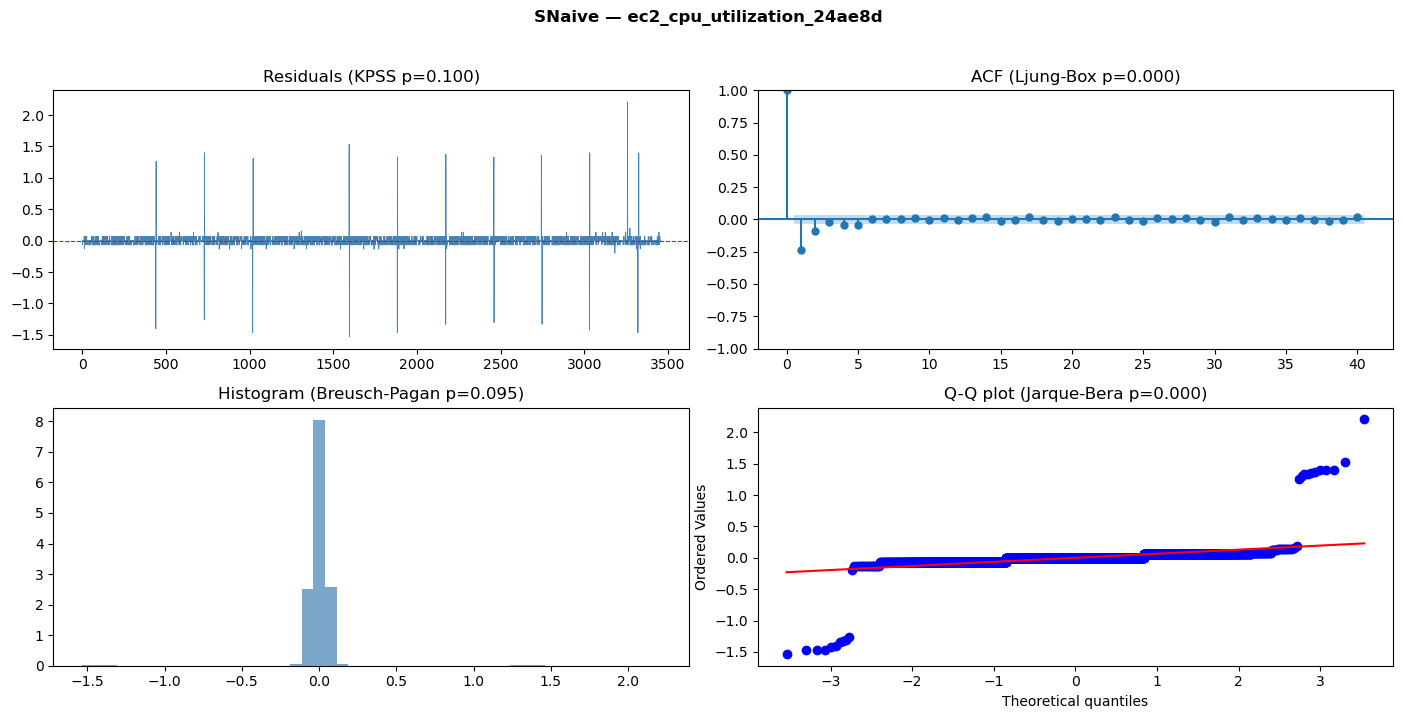

/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")


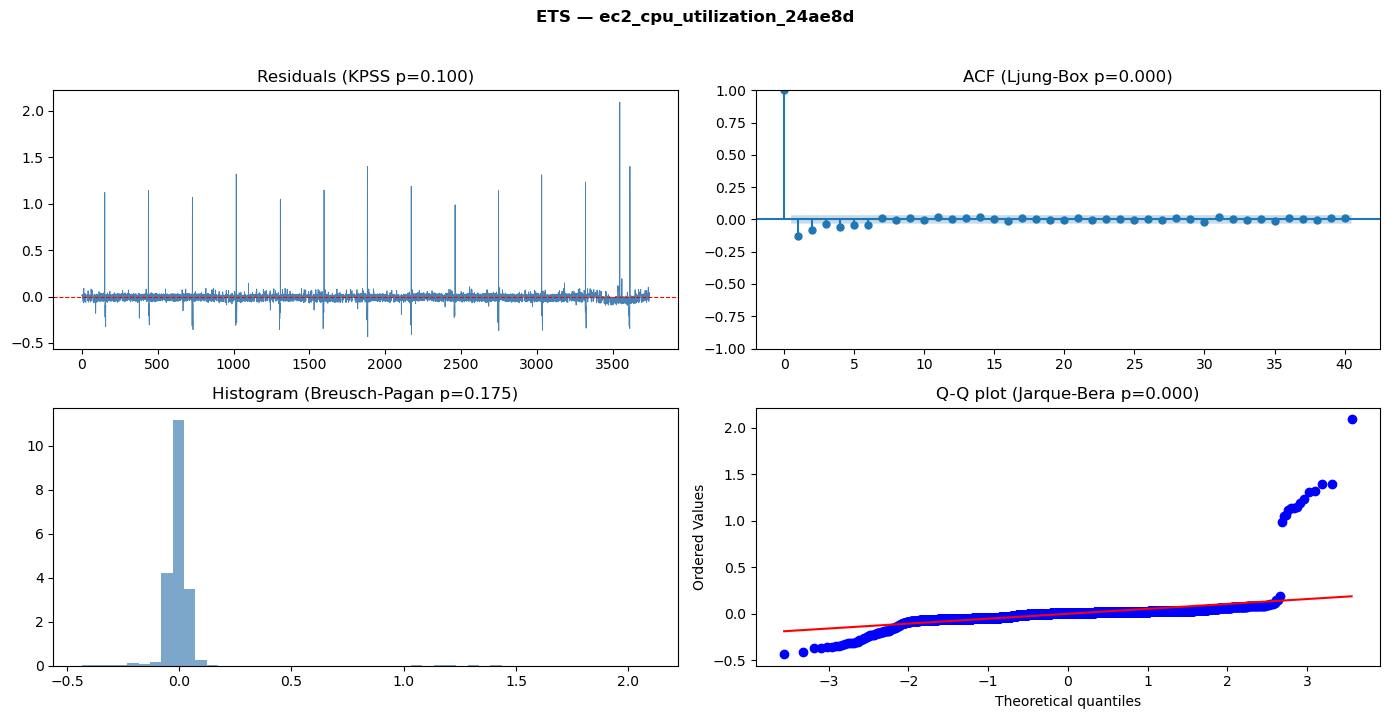

/Users/novikov/src/timeseries_forecast/src/eval.py:72: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  _, kpss_p, *_ = kpss(r.values, regression="c", nlags="auto")


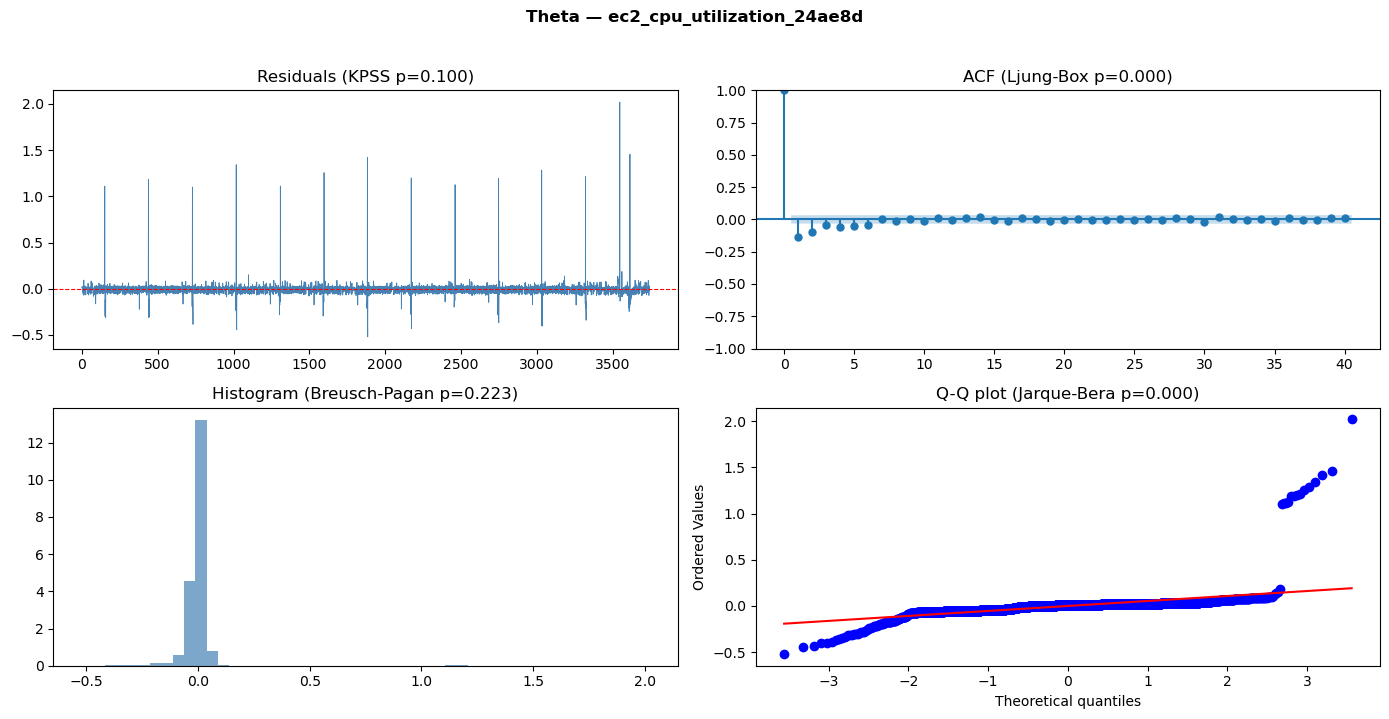

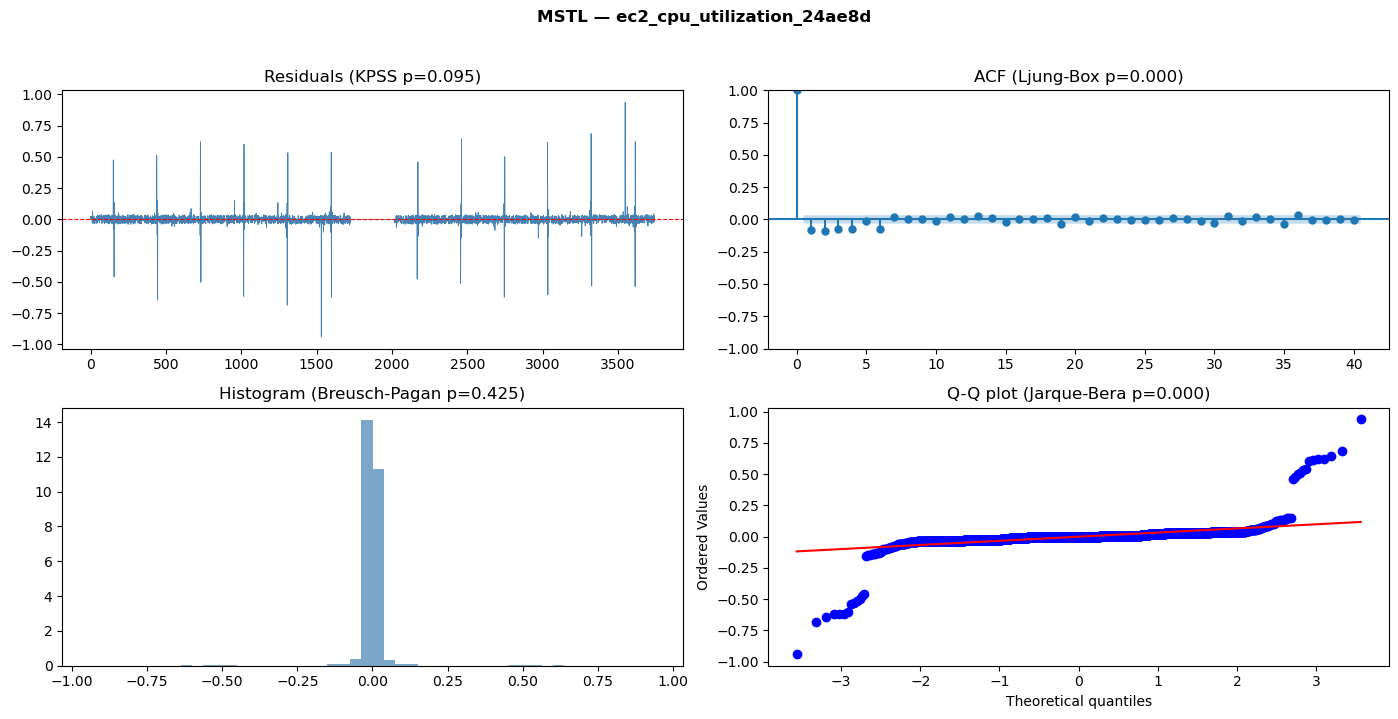

In [4]:
# 4 панели диагностики на один ряд
uid_viz = panel['unique_id'].iloc[0]
sub = fitted_vals[fitted_vals['unique_id'] == uid_viz]
for m in model_names:
    resid = (sub['y'] - sub[m]).dropna().values
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    plot_residual_diagnostics(resid, axes, title=f'{m} - {uid_viz}')
    plt.tight_layout()
    plt.savefig(f'report/figures/03_resid_{m}.png', dpi=120, bbox_inches='tight')
    plt.show()


## Diebold-Mariano test (попарное сравнение)

In [5]:
eval_df = test_fold.merge(fcst, on=['unique_id', 'ds'])

# сравниваю все модели против SeasonalNaive
baseline = 'SNaive'
dm_rows = []
for uid in panel['unique_id'].unique():
    sub = eval_df[eval_df['unique_id'] == uid].sort_values('ds')
    y = sub['y'].values
    f_base = sub[baseline].values
    for m in [n for n in model_names if n != baseline]:
        res = dm_test(y, f_base, sub[m].values, h=1, loss='mae')
        dm_rows.append({'unique_id': uid, 'vs': m, **res})
dm_results = pd.DataFrame(dm_rows)
print('DM-test: f1=SNaive vs f2=<модель>; verdict=кто хуже')
dm_results[['unique_id','vs','dm_stat_hln','p_value','verdict']]


DM-test: f1=SNaive vs f2=<модель>; verdict=кто хуже


,unique_id,vs,dm_stat_hln,p_value,verdict
0,ec2_cpu_utilization_24ae8d,ETS,-1.240776,0.215702,разница не значима
1,ec2_cpu_utilization_24ae8d,Theta,1.640703,0.101955,разница не значима
2,ec2_cpu_utilization_24ae8d,MSTL,-0.049201,0.960793,разница не значима
3,ec2_cpu_utilization_53ea38,ETS,2.582719,0.010298,f1 хуже
4,ec2_cpu_utilization_53ea38,Theta,0.785874,0.432590,разница не значима
5,ec2_cpu_utilization_53ea38,MSTL,-3.867077,0.000136,f2 хуже
6,ec2_cpu_utilization_5f5533,ETS,-0.980654,0.327589,разница не значима
7,ec2_cpu_utilization_5f5533,Theta,-1.749780,0.081225,разница не значима
8,ec2_cpu_utilization_5f5533,MSTL,-15.104877,0.000000,f2 хуже


## Cross-validation: три стратегии

In [6]:
# Стратегия A: Expanding window (по умолчанию)
cv_models = [
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    AutoETS(season_length=DAILY_SEASON, model='ZZA', alias='ETS'),
    MSTL(season_length=[DAILY_SEASON, WEEKLY_SEASON], alias='MSTL'),
]
sf_cv = StatsForecast(models=cv_models, freq=FREQ, n_jobs=-1)

cv_expanding = sf_cv.cross_validation(
    df=panel, h=H, n_windows=5, step_size=H//2, refit=True,
)
print('Expanding CV done:', cv_expanding['cutoff'].nunique(), 'окон')


Expanding CV done: 5 окон


In [7]:
# Стратегия B: Rolling window (фиксированная ширина train)
cv_rolling = sf_cv.cross_validation(
    df=panel, h=H, n_windows=5, step_size=H//2,
    input_size=H * 3, refit=True,   # train фиксированно = 3 суток
)
print('Rolling CV done:', cv_rolling['cutoff'].nunique(), 'окон')


Rolling CV done: 5 окон


In [8]:
# Стратегия C: Fixed window (refit=False - модель учится один раз)
cv_fixed = sf_cv.cross_validation(
    df=panel, h=H, n_windows=5, step_size=H//2,
    input_size=H * 3, refit=False,
)
print('Fixed CV done')


Fixed CV done


In [9]:
from utilsforecast.evaluation import evaluate
metrics, metric_names = make_metrics(seasonality=DAILY_SEASON)

def cv_summary(cv_df, label):
    df = evaluate(cv_df, metrics=metrics, models=[m.alias for m in cv_models],
                  train_df=panel, cutoff_col='cutoff')
    by_metric = df.groupby('metric').mean(numeric_only=True)
    by_metric['strategy'] = label
    return by_metric.reset_index()

summary = pd.concat([
    cv_summary(cv_expanding, 'Expanding'),
    cv_summary(cv_rolling, 'Rolling'),
    cv_summary(cv_fixed, 'Fixed'),
], ignore_index=True)
summary_pivot = summary.pivot_table(index='strategy', columns='metric', values=[m.alias for m in cv_models])
summary_pivot.style.format('{:.3f}').background_gradient(cmap='RdYlGn_r', axis=1)


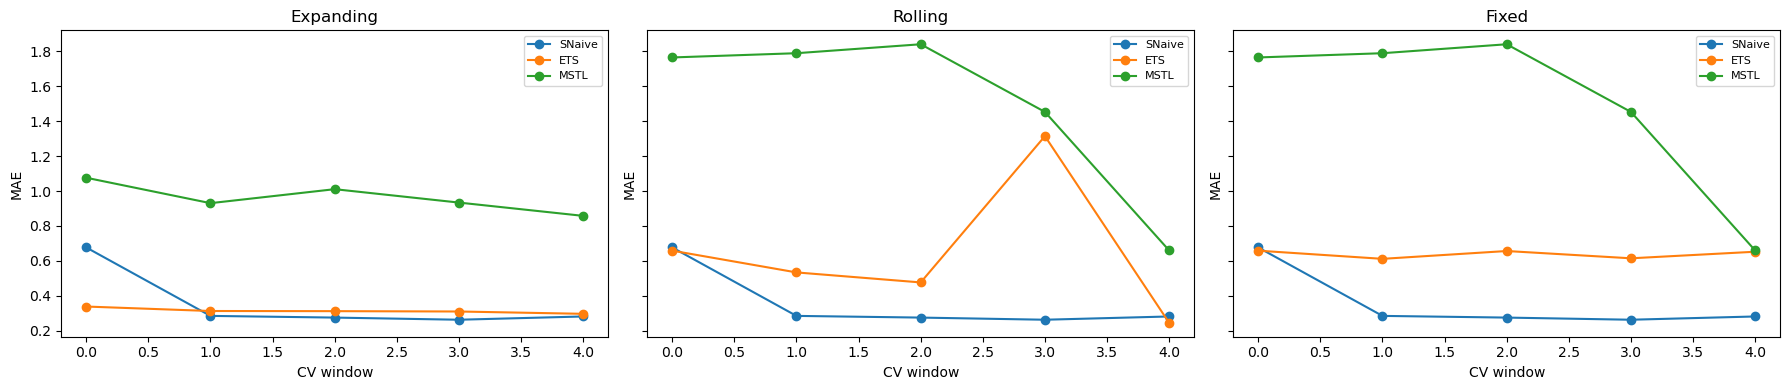

In [10]:
# Визуализация: динамика MAE по окнам для лидера и бейзлайна
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
for ax, (cvdf, name) in zip(axes,
                            [(cv_expanding, 'Expanding'),
                             (cv_rolling, 'Rolling'),
                             (cv_fixed, 'Fixed')]):
    df = evaluate(cvdf, metrics=metrics, models=[m.alias for m in cv_models],
                  train_df=panel, cutoff_col='cutoff')
    df_mae = df[df['metric'] == 'mae']
    for m in [c.alias for c in cv_models]:
        agg = df_mae.groupby('cutoff')[m].mean()
        ax.plot(range(len(agg)), agg.values, marker='o', label=m)
    ax.set_title(name)
    ax.set_xlabel('CV window'); ax.set_ylabel('MAE')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('report/figures/03_cv_strategies.png', dpi=120, bbox_inches='tight')
plt.show()


Expanding - основная оценка, данные накапливаются. Rolling показывает деградацию качества на старых данных. Fixed - насколько устойчива одна обученная модель.

## Probabilistic validation: coverage и conformal

In [11]:
LEVELS = [80, 90]
prob_models = [
    SeasonalNaive(season_length=DAILY_SEASON, alias='SNaive'),
    AutoETS(season_length=DAILY_SEASON, model='ZZA', alias='ETS'),
    MSTL(season_length=[DAILY_SEASON, WEEKLY_SEASON], alias='MSTL'),
]
sf_prob = StatsForecast(models=prob_models, freq=FREQ, n_jobs=-1)
fcst_prob = sf_prob.forecast(df=train_fold, h=H, level=LEVELS)
eval_prob = test_fold.merge(fcst_prob, on=['unique_id', 'ds'])

prob_metrics, prob_names = make_probabilistic_metrics(seasonality=DAILY_SEASON)
m_prob = evaluate_panel(
    eval_df=eval_prob, train_df=train_fold,
    model_names=['SNaive','ETS','MSTL'],
    metrics=prob_metrics, level=LEVELS,
)
m_prob.round(3)


,unique_id,SNaive,ETS,MSTL
metric,,,,
mae,ec2_cpu_utilization_24ae8d,0.047,0.058,0.047
mae,ec2_cpu_utilization_53ea38,0.057,0.048,0.073
mae,ec2_cpu_utilization_5f5533,0.740,0.783,2.452
rmse,ec2_cpu_utilization_24ae8d,0.185,0.109,0.147
rmse,ec2_cpu_utilization_53ea38,0.088,0.072,0.105
rmse,ec2_cpu_utilization_5f5533,0.940,0.999,3.030
smape,ec2_cpu_utilization_24ae8d,0.134,0.254,0.153
smape,ec2_cpu_utilization_53ea38,0.015,0.013,0.020
smape,ec2_cpu_utilization_5f5533,0.010,0.010,0.032


In [12]:
# Coverage: доля фактических точек, попавших в интервал
def actual_coverage(eval_df, model, level):
    lo = f'{model}-lo-{level}'
    hi = f'{model}-hi-{level}'
    if lo not in eval_df.columns:
        return None
    in_interval = (eval_df['y'] >= eval_df[lo]) & (eval_df['y'] <= eval_df[hi])
    return in_interval.groupby(eval_df['unique_id']).mean()

print('Фактическое покрытие 90%-интервала:')
for m in ['SNaive','ETS','MSTL']:
    cov = actual_coverage(eval_prob, m, 90)
    if cov is not None:
        print(f'  {m}:', cov.round(3).to_dict())


Фактическое покрытие 90%-интервала:
  SNaive: {'ec2_cpu_utilization_24ae8d': 0.979, 'ec2_cpu_utilization_53ea38': 0.938, 'ec2_cpu_utilization_5f5533': 1.0}
  ETS: {'ec2_cpu_utilization_24ae8d': 0.615, 'ec2_cpu_utilization_53ea38': 0.927, 'ec2_cpu_utilization_5f5533': 1.0}
  MSTL: {'ec2_cpu_utilization_24ae8d': 0.962, 'ec2_cpu_utilization_53ea38': 0.729, 'ec2_cpu_utilization_5f5533': 0.812}


Если фактический coverage заметно ниже заявленного level, интервалы слишком узкие (overconfident). Калибруется conformal-интервалами (`statsforecast.ConformalIntervals`).

## Стресс-тесты

In [13]:
# стресс-тест: добавляю шум во вторую половину test
def add_volatility_spike(df, uid, factor=2.5, frac=0.5):
    out = df.copy()
    mask = (out['unique_id'] == uid)
    sub = out[mask].sort_values('ds').reset_index(drop=True)
    cutoff = int(len(sub) * (1 - frac))
    rng = np.random.default_rng(42)
    noise = rng.normal(0, sub['y'].std() * (factor - 1), size=len(sub) - cutoff)
    sub.loc[cutoff:, 'y'] = sub.loc[cutoff:, 'y'] + noise[:len(sub) - cutoff]
    out.loc[mask, 'y'] = sub['y'].values
    return out

test_stressed = test_fold.copy()
for uid in panel['unique_id'].unique():
    test_stressed = add_volatility_spike(test_stressed, uid, factor=2.5, frac=0.5)

eval_stressed = test_stressed.merge(fcst, on=['unique_id', 'ds'])
m_stressed = evaluate_panel(
    eval_df=eval_stressed, train_df=train_fold,
    model_names=[m.alias for m in candidates], metrics=metrics,
)
print('Метрики на стресс-тесте (с инжектированным шумом):')
m_stressed.round(3)


Метрики на стресс-тесте (с инжектированным шумом):


,unique_id,SNaive,ETS,Theta,MSTL
metric,,,,,
mae,ec2_cpu_utilization_24ae8d,0.085,0.081,0.071,0.082
mae,ec2_cpu_utilization_53ea38,0.085,0.081,0.085,0.100
mae,ec2_cpu_utilization_5f5533,0.999,1.048,1.046,2.598
rmse,ec2_cpu_utilization_24ae8d,0.210,0.140,0.133,0.175
rmse,ec2_cpu_utilization_53ea38,0.120,0.115,0.119,0.137
rmse,ec2_cpu_utilization_5f5533,1.302,1.351,1.377,3.210
smape,ec2_cpu_utilization_24ae8d,0.291,0.359,0.269,0.293
smape,ec2_cpu_utilization_53ea38,0.023,0.022,0.023,0.027
smape,ec2_cpu_utilization_5f5533,0.013,0.014,0.014,0.034


Сезонные модели (MSTL, SeasonalNaive) деградируют от добавленного шума слабее гладких ETS/Theta.

## Финальный выбор stats-победителя

In [14]:
# Сводная оценка: ранг по среднему по метрикам
def total_score(metrics_df, lower_better=('mae','rmse','smape','mase')):
    df = metrics_df.copy().reset_index()
    score = pd.DataFrame(index=df.columns.difference(['metric','unique_id']))
    for m in lower_better:
        sub = df[df['metric']==m].drop(columns=['metric','unique_id']).mean()
        score[m] = sub.rank()
    return score.sum(axis=1).sort_values()

ranking = total_score(m_prob)
print('Финальный ранг (сумма рангов по точечным метрикам, меньше - лучше):')
print(ranking)

winner = ranking.index[0]
print(f'\nПобедитель stats-моделей: {winner}')

import json
Path('data/processed').mkdir(parents=True, exist_ok=True)
with open('data/processed/winner_stat.json', 'w') as f:
    json.dump({'winner_stat': str(winner), 'h_stat': H}, f)


Финальный ранг (сумма рангов по точечным метрикам, меньше - лучше):
SNaive     5.0
ETS        8.0
MSTL      11.0
dtype: float64

Победитель stats-моделей: SNaive
